# Hybrid PSOGA Method for Feature Selection

In [1]:
import os
import pandas as pd
import numpy as np
import time
import json
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Data
df = pd.read_csv('processed_cicids2017.csv')
df.dropna(inplace=True)

X = df.drop(columns=['Label'])
y = df['Label']
feature_names = X.columns.tolist()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Total Features: {X.shape[1]}")
print(f"Training Samples: {X_train.shape[0]}")

Total Features: 77
Training Samples: 201663


In [3]:
class Hybrid_PSOGA_Selector:
    def __init__(self, X_train, y_train, n_particles=20, n_iterations=10, n_jobs=4):
        self.X_train = X_train
        self.y_train = y_train
        self.n_particles = n_particles
        self.n_iterations = n_iterations
        self.n_jobs = n_jobs
        
        # PSO Parameters
        self.w = 0.7   # Inertia
        self.c1 = 1.4  # Cognitive (Personal)
        self.c2 = 1.4  # Social (Global)
        
        # GA Parameters
        self.mutation_rate = 0.1
        
        # Data Split for Fitness
        self.X_sub, self.X_val, self.y_sub, self.y_val = train_test_split(
            self.X_train, self.y_train, test_size=0.2, random_state=42, stratify=self.y_train
        )
        
        self.n_features = self.X_train.shape[1]
        
        # Initialize Population
        # Positions: Binary [0, 1]
        self.positions = np.random.randint(0, 2, size=(self.n_particles, self.n_features))
        # Velocities: Continuous [-1, 1]
        self.velocities = np.random.uniform(-1, 1, size=(self.n_particles, self.n_features))
        
        # Personal Bests
        self.pbest_pos = self.positions.copy()
        self.pbest_scores = np.zeros(self.n_particles) # Init with 0
        
        # Global Best
        self.gbest_pos = None
        self.gbest_score = -1.0
        
        self.history = {'iteration': [], 'accuracy': [], 'features': [], 'score': []}
        self.training_time = 0
        self.pbar = None

    def calculate_fitness(self, position):
        # 1. Decode solution
        selected_indices = np.where(position == 1)[0]
        if len(selected_indices) == 0:
            return 0.0
            
        # 2. Prepare Data
        X_sub_sel = self.X_sub[:, selected_indices]
        X_val_sel = self.X_val[:, selected_indices]
        
        # 3. Train Classifier
        # Decision Tree (Fast & Standard)
        clf = DecisionTreeClassifier(random_state=42)
        clf.fit(X_sub_sel, self.y_sub)
        pred = clf.predict(X_val_sel)
        
        # 4. Metrics
        accuracy = accuracy_score(self.y_val, pred)
        
        return accuracy

    def _evaluate_batch(self, population):
        scores = Parallel(n_jobs=self.n_jobs, backend="threading")(
            delayed(self.calculate_fitness)(ind) for ind in population
        )
        return np.array(scores)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def run(self):
        print(f"Starting Hybrid PSO-GA with {self.n_particles} particles, {self.n_iterations} iterations...")
        start_time = time.time()
        
        # Initial Evaluation
        scores = self._evaluate_batch(self.positions)
        self.pbest_scores = scores.copy()
        
        best_idx = np.argmax(scores)
        self.gbest_pos = self.positions[best_idx].copy()
        self.gbest_score = scores[best_idx]
        
        self.pbar = tqdm(total=self.n_iterations, desc="Hybrid Evolution")
        
        for iteration in range(self.n_iterations):
            # --- STEP 1: PSO PHASE ---
            # Update Velocity & Position for ALL particles
            for i in range(self.n_particles):
                r1, r2 = np.random.rand(), np.random.rand()
                
                # Velocity Update
                self.velocities[i] = (self.w * self.velocities[i] +
                                      self.c1 * r1 * (self.pbest_pos[i] - self.positions[i]) +
                                      self.c2 * r2 * (self.gbest_pos - self.positions[i]))
                
                # Position Update (Binary PSO logic)
                # Apply sigmoid to velocity to get probability of being 1
                probs = self._sigmoid(self.velocities[i])
                mask = np.random.rand(self.n_features) < probs
                self.positions[i] = mask.astype(int)
                
                # Ensure no empty
                if np.sum(self.positions[i]) == 0:
                    self.positions[i][np.random.randint(0, self.n_features)] = 1

            # Evaluate after PSO move
            current_scores = self._evaluate_batch(self.positions)
            
            # Update Pbests and Gbest
            for i in range(self.n_particles):
                if current_scores[i] > self.pbest_scores[i]:
                    self.pbest_scores[i] = current_scores[i]
                    self.pbest_pos[i] = self.positions[i].copy()
                    
                if current_scores[i] > self.gbest_score:
                    self.gbest_score = current_scores[i]
                    self.gbest_pos = self.positions[i].copy()

            # --- STEP 2: GA PHASE ---
            # Sort population by fitness (ascending)
            # We want to replace the WORST (bottom 50%)
            sorted_indices = np.argsort(current_scores) # Low to High
            half_point = self.n_particles // 2
            
            worst_indices = sorted_indices[:half_point] # The bottom half
            best_indices = sorted_indices[half_point:]  # The top half (Parents)
            
            # Replace worst particles with offspring of best particles
            for i in worst_indices:
                # Select two parents from the top half randomly
                p1_idx = np.random.choice(best_indices)
                p2_idx = np.random.choice(best_indices)
                
                parent1 = self.positions[p1_idx]
                parent2 = self.positions[p2_idx]
                
                # Crossover (Single Point)
                cross_point = np.random.randint(1, self.n_features - 1)
                child = np.concatenate((parent1[:cross_point], parent2[cross_point:]))
                
                # Mutation
                if np.random.rand() < self.mutation_rate:
                    mut_idx = np.random.randint(0, self.n_features)
                    child[mut_idx] = 1 - child[mut_idx]
                    
                # Replace the particle in the main population
                self.positions[i] = child
                # Reset velocity for new particle to 0 or random
                self.velocities[i] = np.random.uniform(-1, 1, size=self.n_features)
                # Reset PBest for this particle to current (as it's a new entity) or keep generic?
                # Logic: It's a new solution, so pbest is its current state (to be eval next)
                # We will evaluate it in next loop, so just set pbest to current state tentatively
                self.pbest_pos[i] = child
                self.pbest_scores[i] = -1 # Force update next time

            # --- Store History for Pareto ---
            sel_feat_count = np.sum(self.gbest_pos)
            self.history['accuracy'].append(self.gbest_score)
            self.history['features'].append(sel_feat_count)
            self.history['iteration'].append(iteration + 1)
            self.history['score'].append(self.gbest_score)

            self.pbar.update(1)
            self.pbar.set_description(f"Best Accuracy: {self.gbest_score:.4f} | Feat: {sel_feat_count}")
            
        end_time = time.time()
        self.training_time = end_time - start_time
        
        self.pbar.close()
        print(f"Hybrid PSO-GA execution complete. Time taken: {self.training_time:.2f} seconds.")
        return self.gbest_pos, self.gbest_score, self.history
    
    def get_runtime(self):
        return self.training_time

In [4]:
# Run Hybrid Algorithm
# Use available CPU cores
n_jobs = os.cpu_count()
print(f"Using {n_jobs} CPU cores for processing.")

hybrid_selector = Hybrid_PSOGA_Selector(X_train_scaled, y_train, n_particles=20, n_iterations=15, n_jobs=n_jobs)
best_mask, best_acc, history = hybrid_selector.run()

Using 12 CPU cores for processing.
Starting Hybrid PSO-GA with 20 particles, 15 iterations...


Hybrid Evolution:   0%|          | 0/15 [00:00<?, ?it/s]

Hybrid PSO-GA execution complete. Time taken: 184.67 seconds.


Algo Complete.
Best Accuracy: 0.9983
Features Selected: 47
Computational Cost (Runtime): 184.6739 seconds
Feature List: ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Max', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Bwd Packets/s', 'Min Packet Length', 'Packet Length Mean', 'Packet Length Std', 'SYN Flag Count', 'RST Flag Count', 'URG Flag Count', 'CWE Flag Count', 'Down/Up Ratio', 'Avg Bwd Segment Size', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max

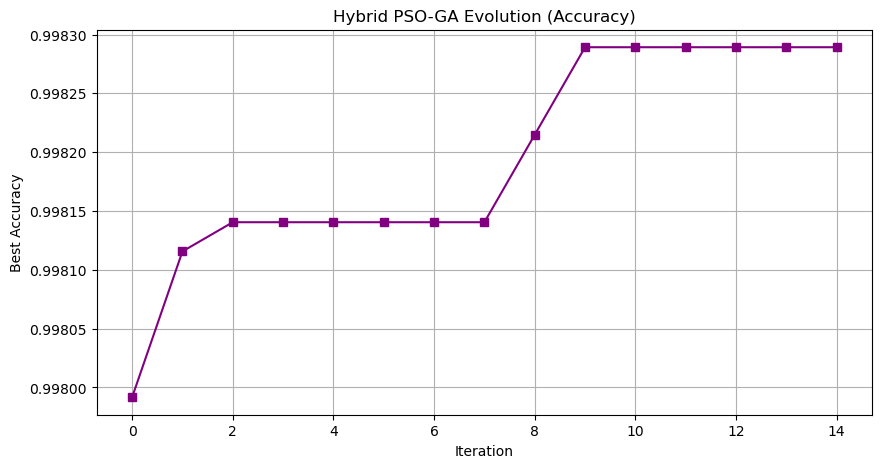

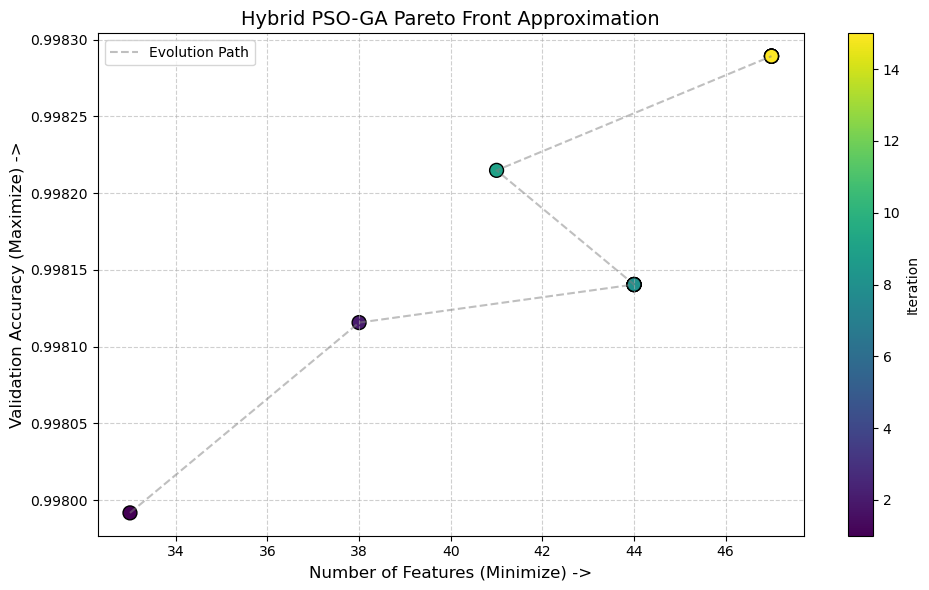

In [5]:
# Results Analysis
selected_indices = np.where(best_mask == 1)[0]
selected_features = [feature_names[i] for i in selected_indices]
runtime = hybrid_selector.get_runtime()

print(f"Algo Complete.")
print(f"Best Accuracy: {best_acc:.4f}")
print(f"Features Selected: {len(selected_features)}")
print(f"Computational Cost (Runtime): {runtime:.4f} seconds")
print(f"Feature List: {selected_features}")

# Plot Convergence
plt.figure(figsize=(10, 5))
plt.plot(history['score'], marker='s', color='purple')
plt.title('Hybrid PSO-GA Evolution (Accuracy)')
plt.xlabel('Iteration')
plt.ylabel('Best Accuracy')
plt.grid(True)
plt.show()

# --- Pareto Front Visualization ---
plt.figure(figsize=(10, 6))
# Evolution Path
plt.plot(history['features'], history['accuracy'], color='gray', linestyle='--', alpha=0.5, label='Evolution Path')
# Points (Iterations)
plt.scatter(history['features'], history['accuracy'], c=history['iteration'], cmap='viridis', s=100, edgecolors='black')

plt.colorbar(label='Iteration')
plt.title('Hybrid PSO-GA Pareto Front Approximation', fontsize=14)
plt.xlabel('Number of Features (Minimize) ->', fontsize=12)
plt.ylabel('Validation Accuracy (Maximize) ->', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


Training Final Classifier on Hybrid PSO-GA Selected Features...

Classification Report (Hybrid PSO-GA Selected Features):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     41901
           1       0.99      1.00      1.00      8515

    accuracy                           1.00     50416
   macro avg       1.00      1.00      1.00     50416
weighted avg       1.00      1.00      1.00     50416

=== Hybrid PSO-GA Final Metrics ===
Accuracy: 0.998413
Precision: 0.998414
Recall: 0.998413
F1-Score: 0.998414
Detection Rate (TPR): 0.996007
False Positive Rate (FPR): 0.001098
Feature Count: 47.000000
Runtime (s): 184.673872


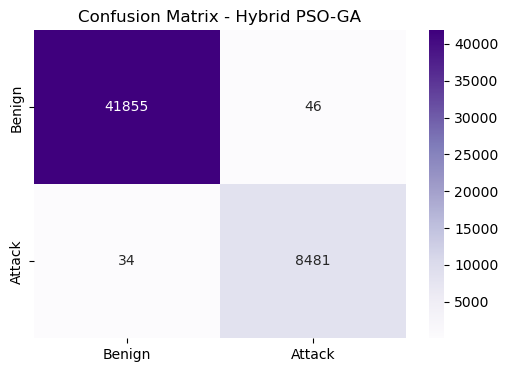

Hybrid PSO-GA metrics saved to results/hybrid_psoga_metrics.json

=== Model Comparison Results ===
                Baseline  Hybrid PSO-GA
Accuracy        0.998155       0.998413
Precision       0.998156       0.998414
Recall          0.998155       0.998413
F1-Score        0.998155       0.998414
Feature Count  77.000000      47.000000


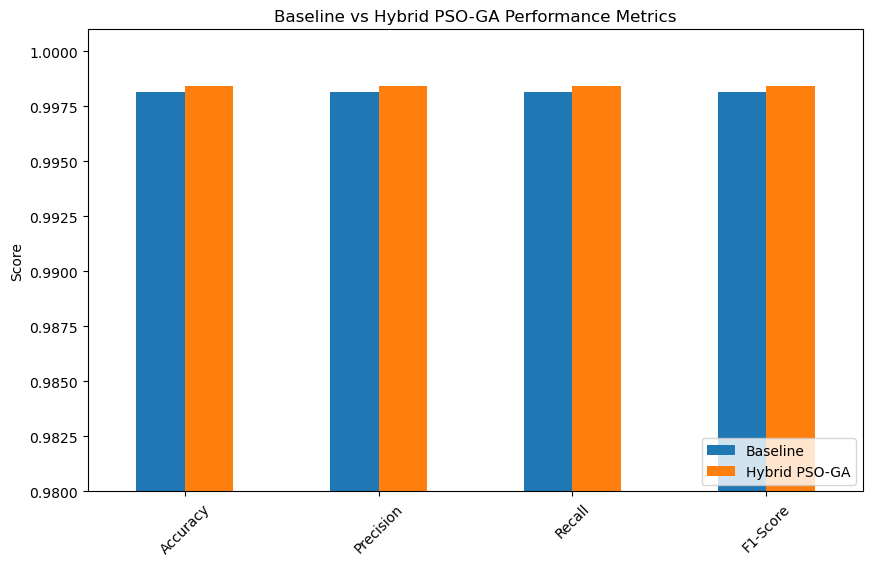


Feature Reduction: 77 -> 47
Reduction Percentage: 38.96%


In [ ]:
# Train Final Model with Hybrid PSO-GA Features
print("\nTraining Final Classifier on Hybrid PSO-GA Selected Features...")

X_train_hyb = X_train_scaled[:, selected_indices]
X_test_hyb = X_test_scaled[:, selected_indices]

final_model = DecisionTreeClassifier(random_state=42)
final_model.fit(X_train_hyb, y_train)

y_pred_hyb = final_model.predict(X_test_hyb)

# Evaluation
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_hyb).ravel()

hyb_acc = accuracy_score(y_test, y_pred_hyb)
hyb_prec = precision_score(y_test, y_pred_hyb, average='weighted')
hyb_rec = recall_score(y_test, y_pred_hyb, average='weighted')
hyb_f1 = f1_score(y_test, y_pred_hyb, average='weighted')

detection_rate_hyb = tp / (tp + fn)
false_positive_rate_hyb = fp / (fp + tn)

print("\nClassification Report (Hybrid PSO-GA Selected Features):")
print(classification_report(y_test, y_pred_hyb))

# Print Metrics Dictionary
hyb_final_metrics = {
    'Accuracy': hyb_acc,
    'Precision': hyb_prec,
    'Recall': hyb_rec,
    'F1-Score': hyb_f1,
    'Detection Rate (TPR)': detection_rate_hyb,
    'False Positive Rate (FPR)': false_positive_rate_hyb,
    'Feature Count': len(selected_features),
    'Runtime (s)': runtime
}

print("=== Hybrid PSO-GA Final Metrics ===")
for k, v in hyb_final_metrics.items():
    print(f"{k}: {v:.6f}")

conf_matrix_hyb = confusion_matrix(y_test, y_pred_hyb)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_hyb, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix - Hybrid PSO-GA')
plt.show()

# --- Comparison with Baseline ---
# 1. Load Baseline Mean Metrics from JSON
try:
    with open('results/baseline_metrics.json', 'r') as f:
        baseline_metrics = json.load(f)
except FileNotFoundError:
    print("Warning: baseline_metrics.json not found. Using default placeholder values.")
    baseline_metrics = {
        'Accuracy': 0.9982,
        'Precision': 0.9982,
        'Recall': 0.9982,
        'F1-Score': 0.9982,
        'Feature Count': 77
    }

hyb_metrics = {
    'Method': 'Hybrid PSO-GA',
    'Accuracy': hyb_acc,
    'Precision': hyb_prec,
    'Recall': hyb_rec,
    'F1-Score': hyb_f1,
    'Detection Rate (TPR)': detection_rate_hyb,
    'False Positive Rate (FPR)': false_positive_rate_hyb,
    'Feature Count': len(selected_features),
    'Runtime (s)': runtime
}

# --- SAVE METRICS to JSON ---
hyb_metrics_path = 'results/hybrid_psoga_metrics.json'
with open(hyb_metrics_path, 'w') as f:
    json.dump(hyb_metrics, f, indent=4)
print(f"Hybrid PSO-GA metrics saved to {hyb_metrics_path}")

# Comparison Table
metrics_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Feature Count']
baseline_filtered = {k: baseline_metrics.get(k, 0) for k in metrics_keys}
hyb_filtered = {k: hyb_metrics.get(k, 0) for k in metrics_keys}

results_df = pd.DataFrame([baseline_filtered, hyb_filtered], index=['Baseline', 'Hybrid PSO-GA'])
print("\n=== Model Comparison Results ===")
print(results_df.T)

# Visualization
results_without_count = results_df.drop('Feature Count', axis=1)
results_without_count.T.plot(kind='bar', figsize=(10, 6))
plt.title('Baseline vs Hybrid PSO-GA Performance Metrics')
plt.ylabel('Score')
plt.ylim(0.98, 1.001) 
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()

print(f"\nFeature Reduction: {baseline_metrics['Feature Count']} -> {hyb_metrics['Feature Count']}")
print(f"Reduction Percentage: {((baseline_metrics['Feature Count'] - hyb_metrics['Feature Count'])/baseline_metrics['Feature Count'])*100:.2f}%")